# DeepMaps explained Step by Step

## 1. Source R file and set python 

In [77]:
library(hdf5r)
library(Matrix)
library(spatstat.core)
library(Signac)
library(Seurat)
source("deepmaps/scRNA_scATAC1.r")

# since we run everything in a sif image, conda crashes and needs to be skipped
Sys.unsetenv("CONDA_PREFIX")
Sys.unsetenv("CONDA_DEFAULT_ENV")
Sys.setenv(CONDA_EXE = "")
Sys.setenv(RETICULATE_PYTHON = "/home/user/miniconda/bin/python")

library(reticulate)

# Patch python_munge_path to return current PATH safely
assignInNamespace(
  "python_munge_path",
  function(python) Sys.getenv("PATH"),  # return valid string, skip conda run
  ns = "reticulate"
)

use_python("/home/user/miniconda/bin/python", required = TRUE)
py_config()

python:         /home/user/miniconda/bin/python
libpython:      /home/user/miniconda/lib/libpython3.8.so
pythonhome:     /home/user/miniconda:/home/user/miniconda
version:        3.8.3 (default, May 19 2020, 18:47:26)  [GCC 7.3.0]
numpy:          /home/user/miniconda/lib/python3.8/site-packages/numpy
numpy_version:  1.21.2

NOTE: Python version was forced by RETICULATE_PYTHON

## 2. Read matched scRNA and scATAC data and quality control

In [ ]:
# download the dataset
system("mkdir -p data")
system("wget https://cf.10xgenomics.com/samples/cell-arc/2.0.0/lymph_node_lymphoma_14k/lymph_node_lymphoma_14k_filtered_feature_bc_matrix.h5 -O data/lymph_node_lymphoma_14k_filtered_feature_bc_matrix.h5")

In [ ]:
####  
## Read matched scRNA and scATAC data and quality control
#input:
#  h5Path: the path of h5 file
#  min_cell: the peak / gene will be removed if the value in the gene / peak with more than min_cell cell is equal to zero, default = 0.1
#output:
#  a seurat object
lymph_obj <- ReadData(h5Path = "data/lymph_node_lymphoma_14k_filtered_feature_bc_matrix.h5", data_type = "scRNA_scATAC", min_cell = 0.001, dataFormat = "h5") 

### 2.1 Expore `lymph_obj`
The Seurat `lymph_obj` is a representation of single-cell expression data for R. Each Seurat object revolves around a set of cells and consists of one or more assay objects, See the [documentation](https://biostatsquid.com/seurat-objects-explained/).

- `lymph_obj[['RNA']]@counts` (genes × cells — how much each gene is expressed) 
- `lymph_obj[['ATAC']]@counts` (peaks × cells — which DNA regions are physically "open") 

We can access the object's slots with `@` and the named elements of a slot with `$`

In [3]:
lymph_obj

An object of class Seurat 
131153 features across 10489 samples within 2 assays 
Active assay: RNA (21440 features, 0 variable features)
 1 other assay present: ATAC

In [4]:
slotNames(lymph_obj)  

[1] "assays"       "meta.data"    "active.assay" "active.ident" "graphs"      
 [6] "neighbors"    "reductions"   "images"       "project.name" "misc"        
[11] "version"      "commands"     "tools"

In [5]:
lymph_obj@assays

$ATAC
ChromatinAssay data with 109713 features for 10489 cells
Variable features: 0 
Genome: 
Annotation present: FALSE 
Motifs present: FALSE 
Fragment files: 0 

$RNA
Assay data with 21440 features for 10489 cells
First 10 features:
 OR4F5, AL627309.1, AL627309.5, LINC01409, LINC01128, LINC00115, FAM41C,
SAMD11, NOC2L, KLHL17 


In [6]:
head(lymph_obj@meta.data)

,orig.ident,nCount_ATAC,nFeature_ATAC,nCount_RNA,nFeature_RNA,percent.mt,atac,rna,mito
,<fct>,<dbl>,<int>,<dbl>,<int>,<dbl>,<otlr.flt>,<otlr.flt>,<otlr.flt>
AAACAGCCAGCCTAAC-1,SeuratProject,1658,875,882,686,0.00000000,FALSE,FALSE,FALSE
AAACAGCCATATTGAC-1,SeuratProject,13001,6135,1982,1431,0.70635721,FALSE,FALSE,FALSE
AAACATGCAAATTCGT-1,SeuratProject,14932,6970,2203,1581,0.09078529,FALSE,FALSE,FALSE
AAACATGCACGAATTT-1,SeuratProject,6982,3382,1924,1382,0.67567568,FALSE,FALSE,FALSE
AAACATGCACTAGCGT-1,SeuratProject,2112,1076,701,595,0.00000000,FALSE,FALSE,FALSE
AAACATGCAGGAACAT-1,SeuratProject,244,128,807,657,0.12391574,FALSE,FALSE,FALSE


In [7]:
lymph_obj[["RNA"]]    # lymph_obj$RNA

Assay data with 21440 features for 10489 cells
First 10 features:
 OR4F5, AL627309.1, AL627309.5, LINC01409, LINC01128, LINC00115, FAM41C,
SAMD11, NOC2L, KLHL17 

In [8]:
lymph_obj[["ATAC"]]    # lymph_obj$ATAC

ChromatinAssay data with 109713 features for 10489 cells
Variable features: 0 
Genome: 
Annotation present: FALSE 
Motifs present: FALSE 
Fragment files: 0 

In [18]:
names(lymph_obj@reductions)
names(lymph_obj@graphs)

NULL

NULL

## 3. Calculate peak-gene regulatory potential matrix [CRE->TG]
For every peak, it computes a regulatory potential score toward every gene using an exponential decay function over genomic distance

In [19]:
##' Calculate peak-gene regulatory potential matrix 
# input:
#  peak_count_matrix: a peak_count matrix from scATAC-seq with peak * cell which return from filterCell function
#  organism: species type GRCh38 / GRCm38, default = GRCh38 
#  pythonPath: the path of python with MAESTRO package
# output:
#  a gene * peak matrix, the elements represent the regulatory potential for peak to gene

ATAC_gene_peak <- CalGenePeakScore(peak_count_matrix = lymph_obj@assays$ATAC@counts, organism = "GRCh38")

### 3.1 Explore the gene-peak matrix

In [24]:
ATAC_gene_peak[1:10, 1:10]

   [[ suppressing 10 column names 'chr1-9795-10696', 'chr1-17061-17939', 'chr1-180997-181703' ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                            
A1BG     . . . . . . . . . .
A1BG-AS1 . . . . . . . . . .
A1CF     . . . . . . . . . .
A2M      . . . . . . . . . .
A2M-AS1  . . . . . . . . . .
A2ML1    . . . . . . . . . .
A2MP1    . . . . . . . . . .
A3GALT2  . . . . . . . . . .
A4GALT   . . . . . . . . . .
A4GNT    . . . . . . . . . .

In [23]:
dim(ATAC_gene_peak)

[1]  28307 109713

In [25]:
head(rownames(ATAC_gene_peak))  # genes
head(colnames(ATAC_gene_peak))  # peaks

[1] "A1BG"     "A1BG-AS1" "A1CF"     "A2M"      "A2M-AS1"  "A2ML1"

[1] "chr1-9795-10696"    "chr1-17061-17939"   "chr1-180997-181703"
[4] "chr1-183968-184757" "chr1-186502-187406" "chr1-191044-191950"

## 4. Calculate gene active score (integration)
Weight both modalities to build the integrated matrix X which contain Gene Activity Scores 

In [ ]:
## Calculate gene active score matrix 
#input:
#  ATAC_gene_peak: a matrix with gene * peak which return from CalGenePeakScore fucntion
#  obj: a seurat object after data preprocessing which return from filterCell function
#  method: the method to integrate scRNA-seq and scATAC-seq velo (velocity) / WNN (weighted nearest neighbor)
#  veloPath: if use velocity method, the veloPath should be provided
#  return.weight: if return.weight = T, return modality integrated weight, else return GAS
#output:
#  GAS matrix with gene * cell, the elements represent the gene activity score in each cell
#  obj: a seurat object with obj[['ATAC_active']] a gene * peak matrix, the elements represent the regulatory potential for peak to gene

GAS_obj <- calculate_GAS_v1(ATAC_gene_peak = ATAC_gene_peak, obj = lymph_obj, method = "wnn")
GAS <- GAS_obj[[1]]
lymph_obj <- GAS_obj[[2]]

### 4.1 Explore GAS matrix

In [29]:
GAS[1:10, 1:10]

   [[ suppressing 10 column names 'AAACAGCCAGCCTAAC-1', 'AAACAGCCATATTGAC-1', 'AAACATGCAAATTCGT-1' ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                                                                            
A1BG        . .         2.080664e-05 .         0.0001687157 . . .           
A1BG-AS1    . .         2.486036e-05 .         0.0100933843 . . .           
A2M         . .         .            0.5932077 .            . . .           
A2M-AS1     . .         2.120276e-04 .         .            . . .           
A2ML1       . .         5.449196e-05 .         0.2794201632 . . .           
A3GALT2     . .         5.566019e-02 .         .            . . 9.228001e-02
A4GALT      . .         .            .         .            . . .           
AAAS        . 0.3077854 1.353192e-02 0.2682948 .            . . .           
AACS        . .         1.259131e-04 .         .            . . 6.036936e-05
AADACL2-AS1 . .         .            .         .            . . .           
                                   
A1BG        .          .           
A1BG-AS1    .          .           
A2

In [30]:
dim(GAS)

[1] 16322 10489

In [31]:
head(rownames(GAS))  # genes
head(colnames(GAS))  # cells

[1] "A1BG"     "A1BG-AS1" "A2M"      "A2M-AS1"  "A2ML1"    "A3GALT2"

[1] "AAACAGCCAGCCTAAC-1" "AAACAGCCATATTGAC-1" "AAACATGCAAATTCGT-1"
[4] "AAACATGCACGAATTT-1" "AAACATGCACTAGCGT-1" "AAACATGCAGGAACAT-1"

## 5. Perform heterogeneous graph transformer (HGT) model on GAS matrix
#### Outputs of `run_HGT`
- `GAS` : Integrated matrix X 
- `cell_hgt_matrix` : cell embeddings (8983 cells x 128)  
- `feature_hgt_matrix` : features embeddings (14737 genes x 128)
- `attention` : attention scores for features and cells (for 16 heads)

In [ ]:
#HGT_result <- run_HGT(GAS = as.matrix(GAS),result_dir='/workdir/vangysel/deepmaps/deepmaps_output', data_type='scRNA_scATAC', envPath=NULL, lr=0.1, epoch=100, n_hid=128, n_heads=16)
#saveRDS(HGT_result, file = "deepmaps_output/HGT_result.rds")

In [32]:
HGT_result <- readRDS("deepmaps_output/HGT_result.rds")

### 5.1 Explore HGT_result

In [33]:
names(HGT_result)

[1] "parameters"         "GAS"                "cell_hgt_matrix"   
[4] "feature_hgt_matrix" "attention"          "result_dir"        
[7] "data_type"

In [34]:
head(HGT_result$GAS)

,AAACAGCCAGCCTAAC-1,AAACAGCCATATTGAC-1,AAACATGCAAATTCGT-1,AAACATGCACGAATTT-1,AAACATGCACTAGCGT-1,AAACATGCAGGAACAT-1,AAACATGCATTTAAGC-1,AAACCAACAACAACAA-1,AAACCAACAATCCTAG-1,AAACCAACACAGAACG-1,⋯,TTTGTGTTCCGTTATT-1,TTTGTGTTCCTGTTCA-1,TTTGTGTTCCTTCAAT-1,TTTGTGTTCTAAGGAG-1,TTTGTGTTCTTACTCG-1,TTTGTTGGTATGGTGC-1,TTTGTTGGTCAATACG-1,TTTGTTGGTCAGGAAG-1,TTTGTTGGTTCAAGAT-1,TTTGTTGGTTTACTTG-1
A1BG,0,0,2.080664e-05,0.0000000,0.0001687157,0,0,0.00000000,0.00000000,0.000000e+00,⋯,0,0.003092488,0,0.000000e+00,0,6.391810e-06,0,0,0.0000000000,0.0000000
A1BG-AS1,0,0,2.486036e-05,0.0000000,0.0100933843,0,0,0.00000000,0.00000000,0.000000e+00,⋯,0,0.013882532,0,0.000000e+00,0,1.209141e-05,0,0,0.0000000000,0.0000000
A2M,0,0,0.000000e+00,0.5932077,0.0000000000,0,0,0.00000000,0.00000000,0.000000e+00,⋯,0,0.000000000,0,0.000000e+00,0,0.000000e+00,0,0,0.0008607145,0.9915475
A2M-AS1,0,0,2.120276e-04,0.0000000,0.0000000000,0,0,0.00000000,0.00000000,0.000000e+00,⋯,0,0.000000000,0,4.364134e-06,0,0.000000e+00,0,0,0.0262876026,0.0000000
A2ML1,0,0,5.449196e-05,0.0000000,0.2794201632,0,0,0.00000000,0.00000000,0.000000e+00,⋯,0,0.000000000,0,4.351124e-05,0,0.000000e+00,0,0,0.0000000000,0.0000000
A3GALT2,0,0,5.566019e-02,0.0000000,0.0000000000,0,0,0.09228001,0.01145813,2.078551e-05,⋯,0,0.000000000,0,0.000000e+00,0,0.000000e+00,0,0,0.0000000000,0.0000000


In [35]:
head(HGT_result$cell_hgt_matrix)

AAACAGCCAGCCTAAC-1,0.01623988,6.050745e-03,-0.008580429,-0.019432638,-1.799035e-05,-0.0041544056,-0.01050455,-0.009532908,-0.012931731,-0.008099442,⋯,0.009222972,0.012561231,-0.003904231,-7.133993e-04,-0.012826380,0.011340200,0.017473053,-0.003913199,-0.001748974,0.0010144290
AAACAGCCATATTGAC-1,0.02062306,4.050674e-03,-0.020260906,-0.010469355,-6.863790e-03,-0.0007649675,-0.01903689,-0.006503302,-0.007565820,-0.012911782,⋯,0.004533543,0.013391952,-0.005504635,7.993314e-03,-0.007997803,0.013273832,0.010848166,-0.007557963,0.003756287,0.0023225849
AAACATGCAAATTCGT-1,0.02038915,-2.900260e-03,-0.008672476,-0.005438876,-1.348601e-02,-0.0001984458,-0.01869535,-0.001368750,-0.010922058,-0.023288453,⋯,0.008197377,0.012349582,-0.005362146,7.307896e-03,-0.003329213,0.015584879,0.008973085,-0.005717416,0.006397501,0.0082207536
AAACATGCACGAATTT-1,0.01845837,3.551652e-03,-0.016452080,-0.009434259,-2.855416e-03,0.0012045559,-0.01904070,-0.008869438,-0.010623358,-0.012274330,⋯,0.004970296,0.020649649,-0.006570256,1.928054e-03,-0.011769152,0.011818847,0.009532138,-0.006643532,0.001484027,0.0006651704
AAACATGCACTAGCGT-1,0.01833908,8.112798e-03,-0.008703294,-0.011947264,-4.312672e-03,-0.0072200373,-0.01387125,-0.008196104,-0.006540013,-0.011823861,⋯,0.007428874,0.008968165,-0.005566680,4.809527e-03,-0.009242047,0.007696882,0.003442076,-0.010797415,0.004120346,-0.0013517576
AAACATGCAGGAACAT-1,0.01748855,-6.674477e-05,-0.012709904,-0.006990964,-1.044044e-03,-0.0021655876,-0.01089109,-0.007122563,-0.006421607,-0.012803000,⋯,0.004436792,0.015003770,-0.006116534,-8.066623e-05,-0.009659245,0.009346155,0.005537238,-0.006274543,0.003806715,-0.0013782338


In [36]:
head(HGT_result$feature_hgt_matrix)

A1BG,-0.0015129865,0.0001240389,0.0056830631,-0.0007935599,0.006270908,-0.005546141,0.0030759901,-0.0089410609,0.0027634036,-0.0006204044,⋯,0.001148936,-0.002612991,0.005476358,0.0017508270,0.0007248784,-0.005885763,-0.0040096943,-3.662477e-04,0.003879881,0.006067417
A1BG-AS1,0.0001735857,-0.0030673891,0.0082144616,0.0001812419,0.005900128,-0.006390175,0.0009126804,-0.0074114990,-0.0009848666,-0.0024695045,⋯,0.005978920,-0.004778543,0.005503717,-0.0009882790,0.0008631499,-0.004543852,0.0007525838,3.452978e-05,0.002656913,0.006115775
A2M,0.0148716457,-0.0060780784,0.0002873325,-0.0051105842,-0.011029525,0.015626861,0.0195343457,-0.0002969611,0.0005665910,0.0145784030,⋯,-0.008198195,-0.009581355,0.032267913,-0.0136511819,-0.0089239748,-0.007073589,-0.0001567177,-3.992455e-03,-0.001154335,0.010997795
A2M-AS1,-0.0078256363,-0.0009295773,0.0075049214,-0.0034195674,0.009814771,-0.010658393,0.0011333319,-0.0071871798,-0.0015279306,-0.0061047017,⋯,0.011300593,0.001459847,0.003179689,0.0023966616,0.0079198545,-0.012780357,0.0029790658,-1.066594e-02,0.003872134,0.007999212
A2ML1,-0.0018155499,-0.0008754290,0.0052173221,-0.0031519462,0.006028294,-0.002660078,0.0025463412,-0.0073487549,0.0018635263,-0.0006526898,⋯,0.001717100,-0.002495544,0.003960235,-0.0006469983,-0.0002212492,-0.005565964,-0.0034531502,-8.581187e-05,0.004231026,0.006619222
A3GALT2,0.0020686295,-0.0012442354,0.0059244512,0.0011780121,0.006181156,-0.006640850,0.0039191009,-0.0091184825,0.0018891834,-0.0005226919,⋯,0.002393869,-0.001722744,0.003970488,0.0014518957,0.0030007269,-0.005273470,-0.0030165303,-4.290368e-04,0.002575943,0.008166706


In [37]:
head(HGT_result$attention)

,gene,cell,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,2,4.004001e-11,-1.658877e-10,4.686160e-11,-2.597456e-11,-5.430125e-11,5.176600e-12,4.091470e-11,-1.308401e-10,-2.136598e-10,8.832412e-11,3.626521e-11,-6.216986e-11,-6.585093e-11,8.315673e-11,-5.961667e-11,8.661473e-11
2,0,4,2.966920e-11,-1.665318e-10,4.775364e-11,-2.378443e-11,-5.159508e-11,-4.815969e-12,3.461786e-11,-1.086065e-10,-1.960049e-10,7.804522e-11,4.266868e-11,-6.136858e-11,-5.566603e-11,9.046749e-11,-4.884344e-11,8.808934e-11
3,0,11,3.963527e-11,-1.622557e-10,4.835291e-11,-2.212086e-11,-4.902470e-11,-5.639359e-12,4.252627e-11,-1.123028e-10,-2.103796e-10,8.770899e-11,3.648941e-11,-5.576450e-11,-6.399877e-11,9.056852e-11,-5.219782e-11,8.788965e-11
4,0,12,4.899916e-11,-1.433827e-10,6.322427e-11,-2.639063e-11,-6.122784e-11,2.189490e-11,5.362280e-11,-1.134907e-10,-2.115770e-10,1.637103e-10,4.057508e-11,-8.182725e-11,-5.853550e-11,7.628915e-11,-7.482591e-11,8.803234e-11
5,0,14,2.979097e-11,-1.666457e-10,4.883585e-11,-2.394943e-11,-5.388439e-11,-5.617815e-12,3.365087e-11,-1.089928e-10,-1.940122e-10,7.986277e-11,4.295164e-11,-6.229301e-11,-5.568508e-11,9.094660e-11,-4.929939e-11,8.755558e-11
6,0,17,3.934356e-11,-1.654494e-10,5.266795e-11,-2.565550e-11,-4.765704e-11,3.490098e-12,4.398223e-11,-1.176619e-10,-2.115707e-10,9.616994e-11,3.476694e-11,-7.392378e-11,-6.087572e-11,8.531922e-11,-5.718779e-11,8.778209e-11


## 6. Cell clustering

In [ ]:
# Align cells
cell_hgt_matrix <- HGT_result[['cell_hgt_matrix']]        # cell embeddings : n_cells x 128
rownames(cell_hgt_matrix) <- colnames(GAS)                # GAS : n_genes x n_cells 
lymph_obj <- lymph_obj[, colnames(GAS)]
cell_hgt_matrix <- cell_hgt_matrix[colnames(GAS),]

# Add HGT as a dimensional reduction
HGT_embedding <- CreateDimReducObject(embeddings = cell_hgt_matrix, key = "HGT_", assay = "RNA")
lymph_obj@reductions[['HGT']] <- HGT_embedding

# Standard preprocessing for RNA assay only
lymph_obj <- FindVariableFeatures(lymph_obj, selection.method = "vst", nfeatures = 2000)
lymph_obj <- ScaleData(lymph_obj, features = VariableFeatures(lymph_obj))

# Compute UMAP from HGT cell embedding 
lymph_obj <-
  RunUMAP(
    lymph_obj,
    reduction = 'HGT',
    dims = 1:ncol(cell_hgt_matrix),
    reduction.name = "umap.rna",
    reduction.key = "rnaUMAP_"
  )

# creates a neighbor graph based on HGT embedding
lymph_obj <-
  FindNeighbors(lymph_obj,
                reduction = "HGT",
                graph.name = "HGT_snn",
                dims = 1:ncol(cell_hgt_matrix))

# cluster the cells
lymph_obj <- FindClusters(lymph_obj, graph.name = "HGT_snn", resolution = 1)

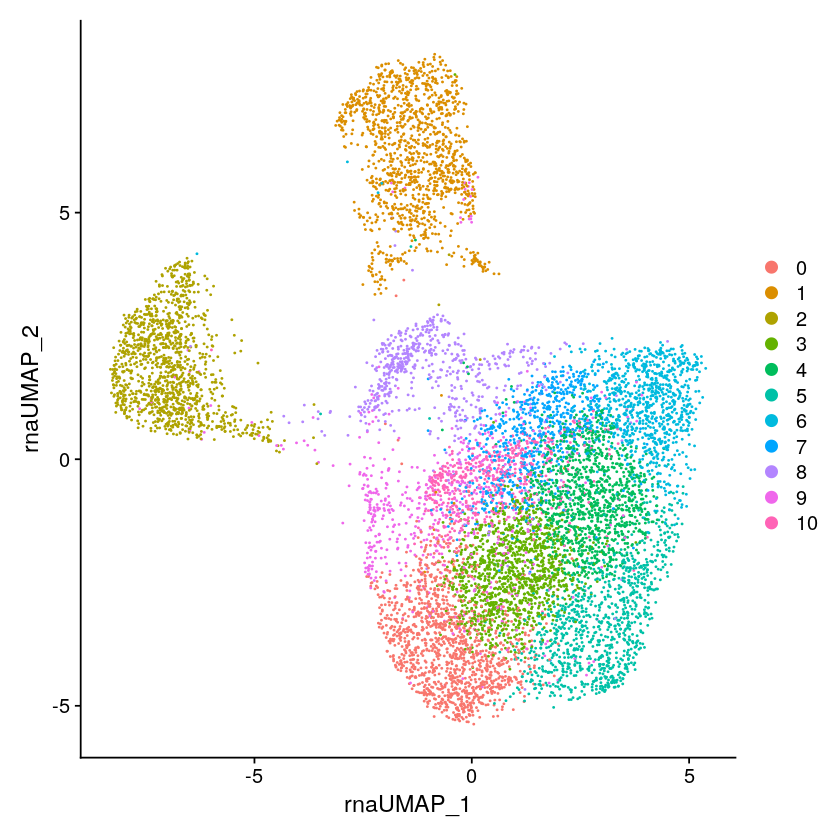

In [44]:
DefaultAssay(lymph_obj) <- "RNA"
DimPlot(lymph_obj, reduction = "umap.rna")

## 7. Calculate cell cluster active gene modules

We use here the `else` branch of the `get_gene_module` function which does the following :

- Add cluster label to each attention edge (in the df `HGT_result$attention`)
- Collapse 16 attention heads into one number (the final attention score between cell $j$ and gene $i$) 
- For each (cluster, gene) pair, the mean attention weight across all cells in that cluster is computed
    - Each cluster gets a vector of size `n_genes`, with values being the mean attention weight that gene received across all cells in that cluster
- Within each cluster i, genes whose mean attention weight exceeds the cluster's mean + 1.6 SD are kept 

In [ ]:
# CT active gene modules calculation
# input:
#  obj: a seurat object
#  GAS: a gene active matrix with gene * cell which return from calculate_GAS function
#  cell_hgt_matrix: cell-embedding matrix which otains from HGT function
#  att: attention matrix with gene-cell * head which obtain from HGT function
#output:
#  co (variable 1): a biological gene module. a list with name CT-i and active gene list in CT-i
co <- get_gene_module(obj = lymph_obj, GAS = GAS, att = HGT_result[['attention']], method = '')

In [55]:
table(Idents(lymph_obj))


   0    1    2    3    4    5    6    7    8    9   10 
1321 1296 1248 1240 1133  964  897  687  606  566  531 

### 7.3 Explore co

The threshold is not asking "is the attention on this particular gene–cell edge high?". It is asking "does this gene, on average across the whole cluster, receive more attention than most other genes do in this cluster?". A gene can have very high attention from a single cell but still be discarded if its cluster-average is unremarkable.
This also means the threshold is cluster-local: $\mu_i$ and $\sigma_i$ are recomputed independently for each cluster. 

In [49]:
names(co)

[1] "ct_0"  "ct_1"  "ct_2"  "ct_3"  "ct_4"  "ct_5"  "ct_6"  "ct_7"  "ct_8" 
[10] "ct_9"  "ct_10"

In [51]:
head(co$ct_0)

[1] "A2M"    "AAK1"   "ABCA1"  "ABCA9"  "ABI3BP" "ABR"

In [54]:
head(Idents(lymph_obj))  # cell barcode : cluster_id

AAACAGCCAGCCTAAC-1 AAACAGCCATATTGAC-1 AAACATGCAAATTCGT-1 AAACATGCACGAATTT-1 
                 6                  0                  0                  4 
AAACATGCACTAGCGT-1 AAACATGCAGGAACAT-1 
                 3                  4 
Levels: 0 1 2 3 4 5 6 7 8 9 10

## 8. Run LISA for TF infer.

We then run LISA on the found gene modules.
LISA takes a list of genes and outputs TF activity scores using epigenomic datasets. We want to predict transcription factors (TFs) and regulators that control each module, infer which TFs are enriched in each cluster's gene set. 


For each cluster LISA will generate a `ct_x.txt.csv` file containing a ranking of TF that regulate cluster `x`


LISA is an external tool that takes a gene list and uses public histone ChIP-seq data (H3K27ac, H3K4me3) to ask: which TFs' binding patterns are most consistent with this gene set being active?

In [ ]:
# gene module save
#input:
#  co: the active gene module from get_gene_module function
#  lisa_path: the path of active gene module to save
#result
#  write gene module to the lisa_path
lisa_path <- "/workdir/vangysel/Deepmaps/lisa_data/"
dir.create(lisa_path, showWarnings = F)
write_GM(co = co, lisa_path = lisa_path)

#run lisa.py in the LISA environment
system(
  paste0(
    "/home/user/miniconda/bin/python deepmaps/run_lisa.py --path ",
    lisa_path,
    " --species ",
    "hg38"
  )
)

## 9. Filter gene with no accessible peak in promoter
Using the `gene_peak` matrix we filter out genes that have zero accessible peaks in their promoter ±2 kb window.

GAS matrix is used to know which genes to consider. A gene for which there is no accessible peak will be removed.

In [58]:
# Filter gene with no accessible peak in promoter 
# input:
#  lymph_obj: a seurat object which return from filterCell function
#  gene_peak: a matrix with gene * peak from scATAC-seq which return from filterCell function 
#  GAS: the GAS matrix with gene * cell which return calculate_GAS function
#  species: hg38 / mm10
#output:
# a matrix with gene * peak. The gene with no accessible peak will be removed
gene_peak_pro <- AccPromoter(obj = lymph_obj, gene_peak = ATAC_gene_peak, GAS = GAS, species = 'hg38')

 chr [1:15352] "LINC01128" "LINC00115" "FAM41C" "NOC2L" "KLHL17" "PLEKHN1" ...


In [65]:
gene_peak_pro[1:10, 1:10]

   [[ suppressing 10 column names 'chr1-9795-10696', 'chr1-17061-17939', 'chr1-180997-181703' ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                             
LINC01128 . . . . . . . . . .
LINC00115 . . . . . . . . . .
FAM41C    . . . . . . . . . .
NOC2L     . . . . . . . . . .
KLHL17    . . . . . . . . . .
PLEKHN1   . . . . . . . . . .
HES4      . . . . . . . . . .
ISG15     . . . . . . . . . .
AGRN      . . . . . . . . . .
AGRN      . . . . . . . . . .

In [64]:
dim(gene_peak_pro)    # ATAC_gene_peak was 28307 x 109713

[1]  15352 109713

## 10. Infer candicate cell type active regulons
We use TF binding site database from JASPAR to infer candidate cell type active regulon and calculate binding affinity from TF to the peak.

### Inputs :

```R 
Calregulon(GAS          = GAS,             # gene × cell matrix
           co           = co,              # list: ct_i → [gene names]
           gene_peak_pro = gene_peak_pro,  # gene × peak matrix (promoter-filtered)
           species       = "hg38",
           jaspar_path   = jaspar_path,    # path to precomputed JASPAR .qsave files
           lisa_path     = lisa_path)      # path to LISA output .csv files
```

The JASPAR database contains TF binding scores for each region (TF binding sites genome-wide)

### Outputs :

- `BA_score` (peak × TF) : holds the JASPAR binding affinity score of each TF to each peak, entries are filled when a JASPAR binding site overlaps a peak. [common to all clusters]
- `gene_TF` (gene × TF) : holds the total regulatory affinity of each TF to each gene via its accessible peaks. Computed from BA_score by matrix multiplication : 

```R
gene_peak_pro  :  gene × peak
BA_score       :  peak × TF
gene_TF        :  gene × TF

gene_TF <- gene_peak_pro %*% BA_score
```

For a given (gene, TF) entry: 
$$
\text{gene_TF}[g,t] = \sum_{p} \text{gene_peak_pro}[g,p] \times \text{BA_score}[p,t]
$$

This sums over all peaks: for each peak, it takes the regulatory potential of that peak for gene $g$ (from MAESTRO) and weights it by the binding affinity of TF $t$ to that peak (from JASPAR). The result is how strongly TF $t$ is predicted to regulate gene $g$ through accessible chromatin. A value of 0 means either no accessible peaks link that TF to that gene, or none of the accessible peaks have a JASPAR motif for that TF.

- `TF filtering` 

TFs whose binding sites were found overlapping the module's accessible peaks form the initial candidate set — purely based on genomic co-occurrence of TF motifs and open chromatin. Then for each gene module, TFs are further filtered using the per cluster created files from LISA.TFs with `summary_p_value < 0.05` are kept, `intersect()` retains only TFs that are both supported by JASPAR motif overlap and by LISA chromatin evidence

- `ct_regulon_v1` : for each cluster we have candidates TF from which we find sets of TF regulons, named TF_ctX. We first iterate over selected TFs then assign TG to it, using $gene\_{TF[g, t]} > 0$ to do so. 


In [78]:
## infer ct active regulons
# input:
# GAS: the GAS matrix with gene * cell which return calculate_GAS function
# co: a list of bio network which reture from gene_ function 
# gene_peak_pro: the matrix with gene * peak which return AccPromoter function
# species: human / mouse (human = "hg38", mouse = "mm10" )
# jaspar_path: if speices == human, the TF binding RData absolute path of hg38 should be provided,if speices == mouse, the TF binding RData absolute path of mm10 should be provided
# lisa_path: the co saved path
#output:
# BA_score a TF binding affinity matrix with TF * peak, the elements in the matrix is the binding power of TF to peak 
# ct_regulon: candidate cell type active regulon
# TFinGAS: TRUE / FALSE, if number of the intersection of candidate TF from LISA and gene in GAS > 50 TFinGAS will be true, else it will be false

jaspar_path = "/workdir/vangysel/Deepmaps/jaspar_data/"
dir.create(jaspar_path, showWarnings = F)

pre_regulon_res <- Calregulon(GAS = GAS, co = co, gene_peak_pro = gene_peak_pro, species = "hg38", jaspar_path = jaspar_path, lisa_path = lisa_path)
BA_score <- pre_regulon_res[[1]]
ct_regulon_v1 <- pre_regulon_res[[2]]
TFinGAS<- pre_regulon_res[[3]]

In [79]:
head(BA_score)   # peaks x TF

,RUNX1,TFAP2A,PAX5,NR2F1,E2F1,NFIL3,ELK1,FOXF2,FOXC1,GATA1,⋯,ZNF740,CUX1,CUX2,ONECUT2,ONECUT3,E2F7,ELK3,ERF,ETV1,ETV2
chr1-9795-10696,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1-17061-17939,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1-180997-181703,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1-183968-184757,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1-186502-187406,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr1-191044-191950,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [82]:
head(names(ct_regulon_v1))    # TF_ctX

[1] "IRF1_ct0"   "MEF2A_ct0"  "SPI1_ct0"   "SPIB_ct0"   "CTCF_ct0"  
[6] "TCF7L2_ct0"

In [84]:
length(ct_regulon_v1)

[1] 618

In [90]:
table(labels)

labels
 ct0  ct1 ct10  ct2  ct3  ct4  ct5  ct6  ct7  ct8  ct9 
  54   57   57   59   57   55   59   58   55   54   53 

In [91]:
# recover TF names
tfs <- sapply(strsplit(names(ct_regulon_v1), "_"), `[`, 1)
table(tfs)

tfs
  ATF3  CEBPA  CEBPB   CTCF   CUX1   E2F1   E2F7    EHF    ERG   ESR1   ETV6 
    11     11     11     11      9      7     11     11     11     11     11 
  FLI1    FOS  FOSL1  FOXH1  FOXP1  GATA4   GLI2    HLF  HNF1B  HOXC9   HSF1 
    11     11     11     11     11     11     11     11     11     11     11 
  IRF1    JUN   JUNB   JUND   LHX2   MAFF   MAFK    MAX  MEF2A  MEF2B    MYB 
    11     11     11     11     11     11     11     11     11     11     11 
   MYC   MZF1 NFATC1   NFIC  NR2F1  NR3C1 POU2F2  PPARG  PRDM1   RARA   RELA 
    11     11      3     11      9     11      7     11     11     11     11 
  REST  RUNX1  RUNX2  RUNX3  SOX10    SP1   SPI1   SPIB  STAT1  TBX21 TCF7L2 
    11     11     11     11     11      4     11     11     11     11     11 
 TEAD1   TP53   TP63 ZNF263 
    11     11     11      7 

In [81]:
TFinGAS

[1] TRUE

## 11. Combine same TF

In [92]:
# combine same TF
#input:
# gene_peak_pro: a matrix with gene * peak. The gene with no accessible peak will be removed which return from AccPromoter function
# BA_score: a TF binding affinity matrix with TF * peak, the elements in the matrix is the binding power of TF to peak which returen from Calregulon function
#output:
# peak_TF: a matrix with peak * TF without repeat TF
peak_TF <- uni(gene_peak_pro = gene_peak_pro, BA_score = BA_score)
head(peak_TF[1:3,1:10])  # a filtered version of BA_score !

,RUNX1,TFAP2A,PAX5,NR2F1,E2F1,NFIL3,ELK1,FOXF2,FOXC1,GATA1
chr1-9795-10696,0,0,0,0,0,0,0,0,0,0
chr1-17061-17939,0,0,0,0,0,0,0,0,0,0
chr1-180997-181703,0,0,0,0,0,0,0,0,0,0


## 12. Calculate regulatory Intensive (RI) score in cell level and infer cell type active regulon
`RI_cell()` computes a score for every TF→gene edge in every cell

For each cell the RI score is computed as : 

$$
\mathrm{hhh}_{g,t}
= \sum_{p}
\underbrace{\mathrm{peak\_cell}_{p,j}}_{\text{open in cell } j}
\times
\underbrace{\mathrm{gene\_peak}_{g,p}}_{\text{MAESTRO potential}}
\times
\underbrace{\mathrm{peak\_TF}_{p,t}}_{\text{JASPAR affinity}}
$$

A peak only contributes if it is simultaneously open in cell $j$, has regulatory potential for gene $g$, and has a JASPAR motif for TF t. If any condition fails for all peaks, hhh[g, t] = 0.

In [ ]:
# Regulatory Intensive (RI) score in cell level
# input:
#  obj: a seurat object which return from filterCell function
#  ct_regulon: cell type active regulon
#  GAS: the GAS matrix with gene * cell which return calculate_GAS function
#  gene_peak_pro: the matrix with gene * peak which return from AccPromoter function
#  peak_TF: the matrix with peak * TF which return from uni function
#  graph.out: a factor variable. The predict cell cluster which return from get_gene_module function
#output:
#  RI_C: a regulatory intensive matrix with TF-gene pair * cell, the element means the intensity of TF to gene in each cell
graph.out <- as.factor(lymph_obj$seurat_clusters)
RI_C <- RI_cell(obj = lymph_obj, ct_regulon = ct_regulon_v1, GAS = GAS, gene_peak_pro = gene_peak_pro, peak_TF = peak_TF, graph.out = graph.out)

In [95]:
head(RI_C[1:3,1:10])

IRF1_A2M,0,0,0,0,0,0,0,0,0,0
IRF1_AAK1,0,0,0,0,0,0,0,0,0,0
IRF1_ABCA1,0,0,0,0,0,0,0,0,0,0


In [97]:
dim(RI_C)

[1] 10260 10489

## 13. Calculate regulon active score1 (RAS1)
For each cluster $i$, average RI_C across its cells. `RI_CT[pair, cluster]` = mean RI score of that TF→gene edge across all cells in that cluster. Pairs that are never active in a cluster get 0.

| Output | Shape | Meaning |
|---|---|---|
| `RAS_CT` | TF × cluster | Mean regulon activity score in each cluster. Used for heatmaps and master TF ranking |
| `RI_CT` | TF_gene × cluster | Mean RI per edge per cluster. Used in `masterFac()` as edge weights in the GRN |
| `ct_regulon` | named list | Refined version of `ct_regulon_v1` — only edges with RI > 0 in the target cluster survive |
| `RAS_C1` | TF × cell | Per-cell regulon activity. Fed into `CalRAS2()` then `calDR()` for differential regulon detection |

In [ ]:
# input:
#  RI_C: a regulatory intensive matrix with TF-gene pair * cell, the element means the intensity of TF to gene in each cell
#  ct_regulon: cell type active regulon
#  graph.out: a factor variable. The cell cluster which return from get_gene_module function
#  TFinGAS: TRUE / FALSE, if number of the intersection of candidate TF from LISA and gene in GAS > 50 TFinGAS will be true, else it will be false which return from Calregulon function
#output:
#  RAS_CT: regulon active score in cell type level
#  RI_CT: regulatory intensive score in cell type level
#  ct-regulon: cell type active regulon
#  RAS_C1: a matrix regulon-CT * cell, regulatory active score in cell level
regulon_res <- calRAS(RI_C = RI_C, ct_regulon = ct_regulon_v1, graph.out = graph.out, TFinGAS = TFinGAS)
RAS_CT <- regulon_res[[1]]   # TF × cluster
RI_CT  <- regulon_res[[2]]   # TF_gene × cluster
ct_regulon <- regulon_res[[3]]  # refined regulons
RAS_C1 <- regulon_res[[4]]   # TF × cell

In [99]:
head(ct_regulon[1:3])

$IRF1_ct0
 [1] "ABR"       "ALDH1A1"   "ANK2"      "ANKRD22"   "APOE"      "ARRB1"    
 [7] "ATG7"      "ATP8B4"    "ATXN1"     "B4GALT5"   "BICDL1"    "BIRC3"    
[13] "CADM1"     "CAMK4"     "CBLB"      "CCL3"      "CD6"       "CD96"     
[19] "CDC42SE2"  "CHST11"    "CPQ"       "CSF2RB"    "CTSC"      "DAPK1"    
[25] "EDA"       "ENOX1"     "ENPP1"     "FAM184A"   "FCHO2"     "FKBP5"    
[31] "FMNL2"     "FNIP2"     "GK"        "GPRIN3"    "IFNG"      "IKZF2"    
[37] "IQGAP2"    "LINC01374" "ME1"       "MGLL"      "NCALD"     "NLRC5"    
[43] "NR1H3"     "PALLD"     "PCNX2"     "PDE4B"     "PITPNC1"   "PRF1"     
[49] "PTGDS"     "PTPRB"     "PTPRJ"     "QKI"       "RAI14"     "RASGRP1"  
[55] "RBPJ"      "RNF144B"   "RNF213"    "RTN1"      "SAMHD1"    "SAT1"     
[61] "SGIP1"     "SHC4"      "SKAP1"     "TSHZ2"     "UNC5C"     "UTY"      
[67] "ZEB2"     

$MEF2A_ct0
 [1] "A2M"       "ANPEP"     "AOAH"      "APOE"      "ARHGAP6"   "ARHGEF10L"
 [7] "ASAP1"     "ATP9A"     "B4GALT5"   "CCL4L2"    "CD163"     "CD247"    
[13] "CD38"      "CD96"      "CDC42SE2"  "CENPP"     "CHST11"    "DMXL2"    
[19] "EFNA5"     "ENOX1"     "ENPP1"     "FAF1"      "FLT1"      "FMNL2"    
[25] "FNBP1L"    "GK"        "GLIS3"     "GPC5"      "IFNG"      "IL18"     
[31] "JARID2"    "KYNU"      "LIMCH1"    "LINC01478" "LRBA"      "LYST"     
[37] "MADD"      "MAML3"     "MBP"       "MCTP1"     "MSI2"      "MT1G"     
[43] "MT1H"      "NCALD"     "NR1H3"     "NXN"       "P2RX7"     "PAG1"     
[49] "PCNX2"     "PHACTR2"   "RAB31"     "RBM47"     "RBPJ"      "RNF130"   
[55] "SAMSN1"    "SASH1"     "SAT1"      "SGIP1"     "SGPP2"     "SLC22A23" 
[61] "TRAF3"     "TTC28"     "USP34"     "WHRN"      "WWOX"      "ZEB2"     
[67] "ZNF366"   

$SPI1_ct0
 [1] "A2M"    "ATP9A"  "CASC15" "CCL3"   "CD2"    "CD247"  "CDK14"  "COL4A2"
 [9] "FYN"    "GPRIN3" "GTDC1"  "IKZF2"  "ITGA4"  "MGLL"   "MYO1E"  "NCALD" 
[17] "PSD3"   "RNF19A" "RNF213" "RTN1"   "RUNX3"  "SAMSN1" "SH3RF3" "TNS3"  
[25] "TSPEAR" "USP34"  "WDFY4"  "ZEB2"

In [102]:
head(RI_CT)     # TF_gene × cluster

,ct0,ct1,ct2,ct3,ct4,ct5,ct6,ct7,ct8,ct9,ct10
IRF1_ABCA1,0.000000e+00,7.324639e-04,0.0000000000,0.0007655429,0.0008378405,0.000000000,0.0000000000,0.00000000,0.00000000,0.00000000,0.00000000
IRF1_ABCA9,0.000000e+00,1.380347e-04,0.0004300313,0.0001442686,0.0000000000,0.000000000,0.0000000000,0.00000000,0.00000000,0.00000000,0.00000000
IRF1_ABR,8.925694e-02,1.053438e-01,0.0149175624,0.0400368127,0.0328634032,0.019312363,0.0345914491,0.02709915,0.05120219,0.01096414,0.02337366
IRF1_AGAP1,0.000000e+00,0.000000e+00,0.0009993800,0.0000000000,0.0000000000,0.000000000,0.0000000000,0.00000000,0.00000000,0.00000000,0.00000000
IRF1_ALDH1A1,2.218915e-06,1.130859e-06,0.0000000000,0.0000000000,0.0000000000,0.000000000,0.0000000000,0.00000000,0.00000000,0.00000000,0.00000000
IRF1_ANK2,8.988764e-04,1.771973e-03,0.0058973289,0.0006286061,0.0000000000,0.001176344,0.0001976168,0.00000000,0.00000000,0.00000000,0.00000000


## 14. Calculate RAS2 same topology in a row

In [ ]:
##calculate RAS(2) same topology in a row
# calculate regulon active score in cell level / cell type level
# input:
#  ct_regulon: a matrix with gene * peak from scATAC-seq which return from get_gene_module function
#  graph.out: a factor variable. The predict cell cluster which return from get_gene_module function 
#output:
#  RAS_C2: a matrix with regulon-CT * cell. Regulon active score in cell type level

RAS_C2 <- CalRAS2(ct_regulon, graph.out)

In [106]:
head(RAS_C2[1:3,1:10])  # regulon-CT * cell

   [[ suppressing 10 column names 'AAACAGCCAGCCTAAC-1', 'AAACAGCCATATTGAC-1', 'AAACATGCAAATTCGT-1' ... ]]



3 x 10 sparse Matrix of class "dgCMatrix"
                                                            
IRF1_ct0  . .            .            0.09010482 . . . . . .
MEF2A_ct0 . 2.824409e-05 .            .          . . . . . .
SPI1_ct0  . .            0.0006408072 .          . . . . . .

## 15. Calculate master TF

In [107]:
##calculate master TF
#find master TF and master gene, build a cell type gene regulatory network
#input:
# ct_regulon: cell type active regulon
# RI_CT: regulatory intensive score in cell type level which return from calRAS funciton 
#output:
# TF_cen: TF centrality score in each CT
# gene_cen: gene centrality score in each CT
# network: adjcent matrix in a CT
masterTF <- masterFac(ct_regulon = ct_regulon, RI_CT = RI_CT)
TF_cen <- masterTF[[1]]
gene_cen <- masterTF[[2]]
network <- masterTF[[3]]

In [111]:
head(network)

## 16. Calculate cell type specific regulon

In [114]:
##calculate DR
#infer cell type specific regulon
#input:
#  RAS_C2: a matrix with regulon-CT * cell. Regulon active score in cell type level
#  graph.out: a factor variable. The predict cell cluster which return from get_gene_module function 
#  only.pos: only print positive regulons
#  lfcThre: logFoldchange threshold, default = 0.25
#  pvalThres: pvalue threshold, default = 0.05
#output:
#  DR: differnent regulons. 

DR <-
  calDR_v2(
    RAS_C2,
    graph.out,
  )
DR[1:2]

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Warning message in FindMarkers.default(object = data.use, slot = data.slot, counts = counts, :
"No features pass logfc.threshold threshold; returning empty data.frame"
Calculating cluster 7

Warning message in FindMarkers.default(object = data.use, slot = data.slot, counts = counts, :
"No features pass logfc.threshold threshold; returning empty data.frame"
Calculating cluster 8

Calculating cluster 9

Warning message in FindMarkers.default(object = data.use, slot = data.slot, counts = counts, :
"No features pass logfc.threshold threshold; returning empty data.frame"
Calculating cluster 10



,p_val,avg_log2FC
,<dbl>,<dbl>
CTCF-ct0,3.224439e-26,1.519404e-03
ZNF263-ct0,1.121270e-21,8.756957e-04
IRF1-ct0,5.498333e-17,2.220362e-03
JUNB-ct0,7.502169e-16,1.420515e-02
PRDM1-ct0,8.379948e-16,4.161446e-03
MEF2A-ct0,1.767414e-14,5.016058e-04
TEAD1-ct0,1.422216e-13,2.572272e-03
HNF1B-ct0,1.981062e-13,7.466159e-03
SOX10-ct0,2.846458e-13,4.826217e-03
